<a href="https://colab.research.google.com/github/c-mmonteiro/estudos/blob/main/Estudo_Minimos_Quadrados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudo de minimos quadrados



In [74]:
!pip install puncc

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import random

from deel.puncc.regression import SplitCP
from deel.puncc.api.prediction import BasePredictor

from deel.puncc.metrics import regression_mean_coverage
from deel.puncc.metrics import regression_sharpness


# 1. Classe do modelo de ajuste (SciPy)

#### Função para ajuste dos parâmetros

$b(t) = y1 + y2*(t - t0)$



In [76]:
class AjusteCurva():
  def __init__(self, t0):
    self.t0 = t0

  def func_ajuste(self, t, y1, y2):
    return y1 + y2*(t - self.t0)

  def fit(self, X, y):
    popt, pcov = curve_fit(self.func_ajuste, X, y)

    print(f'Resultado do fit:')

    self.y1 = popt[0]
    self.y2 = popt[1]
    self.popt = popt
    print(f'y1: {self.y1:.4f} \ny2: {self.y2:.5f}')

    #Desvio padrão de cada parâmetro
    perr = np.sqrt(np.diag(pcov))
    self.s_y1 = perr[0]
    self.s_y2 = perr[1]
    print(f'---\ns(y1) = {self.s_y1:.4f} \ns(y2) = {perr[1]:.5f}')

    #Coeficiente de Correlação
    self.r = pcov[1,0] / (perr[0]*perr[1])
    print(f'---\nr = {self.r:.3f}')

    #Devio padrão do erro (residuo)
    y_pred = self.func_ajuste(np.array(X), *self.popt)
    residuals = np.array(y) - y_pred
    self.std_pad_erro = np.sqrt(np.sum(residuals**2) / (len(y) - 2))
    print(f's(erro) = {self.std_pad_erro:.4f}')

    return self

  def predict(self, X):
    return self.func_ajuste(X, *self.popt)

In [77]:
t0 = 20
t_student = 2

# 2. Replicação do exemplo H3 do GUM-100

### Dados usados

Onde:
- t é a temperatura medida
- b é o fator de correção  ($b = t_R - t$)
- $t0 = 20°C$

In [78]:
b = [-0.171,
     -0.169,
     -0.166,
     -0.159,
     -0.164,
     -0.165,
     -0.156,
     -0.157,
     -0.159,
     -0.161,
     -0.160]

t = [21.521,
     22.012,
     22.512,
     23.003,
     23.507,
     23.999,
     24.513,
     25.002,
     25.503,
     26.010,
     26.511]
n = len(b)


#### Define o modelo e calcula os parâmetros

In [79]:
model = AjusteCurva(20)
model.fit(t, b)

Resultado do fit:
y1: -0.1712 
y2: 0.00218
---
s(y1) = 0.0029 
s(y2) = 0.00067
---
r = -0.930
s(erro) = 0.0035


#### Cálculo da Correção com Incerteza do Modelo

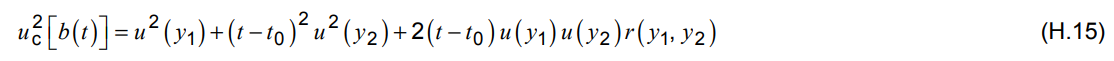

In [80]:
print(f'\n\nResultado da medição com Incerteza do Modelo:')
t_test = 30

y_pred = model.predict(30)
print(f'b({t_test} °C) = {y_pred:.4f} °C')

uc = np.sqrt(model.s_y1**2 + ((t_test-model.t0)**2)*(model.s_y2**2) + 2*(t_test-model.t0)*model.s_y1*model.s_y2*model.r)
print(f'uc[b({t_test} °C)] = {uc:.4f} °C')

ip = uc*t_student
print(f'b({t_test}) = {y_pred:.4f} \u00B1 {ip:.4f} °C')

print(f'T = {(t_test + y_pred):.4f} \u00B1 {ip:.4f} °C')



Resultado da medição com Incerteza do Modelo:
b(30 °C) = -0.1494 °C
uc[b(30 °C)] = 0.0041 °C
b(30) = -0.1494 ± 0.0083 °C
T = 29.8506 ± 0.0083 °C


# 3. Aplicação com dados gerados

### Geração de dados

Onde:
- t é a temperatura medida
- b é o fator de correção, onde $t_R$ é a temperatura de referencia

$b = t_R - t$


- $t_0 = 20°C$

Ruido:
A geração dos dados foi feita com erro sistemático de -0,12 e ruido de medição com distribuição normal e desvio padrão de 0,1

In [102]:
erro_sistematico = -0.12
erro_aleatorio = 0.1

limite_inferior_modelo = 22
limite_superior_modelo = 27
passo_modelo = 0.25

limite_inferior_teste = 22
limite_superior_teste = 24
passo_teste = 0.1

In [103]:
tr_list = []
t_list = []
b_list = []
for tr in np.arange(limite_inferior_modelo, limite_superior_modelo, passo_modelo):
  sample = tr + random.gauss(erro_sistematico, erro_aleatorio)
  t_list.append(sample)
  b_list.append(tr - sample)
  tr_list.append(tr)


In [104]:
model_2 = AjusteCurva(t0)
model_2.fit(t_list, b_list)

Resultado do fit:
y1: 0.2008 
y2: -0.01463
---
s(y1) = 0.0765 
s(y2) = 0.01708
---
r = -0.945
s(erro) = 0.1114


## 3.1 Avaliando a incerteza por meio da propagação de incerteza

#### Cálculo da medição com a Incerteza da correção

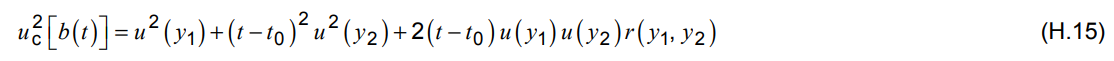

Ao final, combina a uc (incerteza combinada) do modelo com a u (incerteza padrão) da medição, obtendo $uc_f$ (incerteza combinada final)

$uc_f = \sqrt{uc^2 + u^2}$

Por último, multiplica a $uc_f$ pelo fator de t-Student para 95% com grau de liberdade de 22, uma vez que foram utilizadas 24 amostras para definição do y1 e y2.

Text(0, 0.5, 'Temperatura Medida')

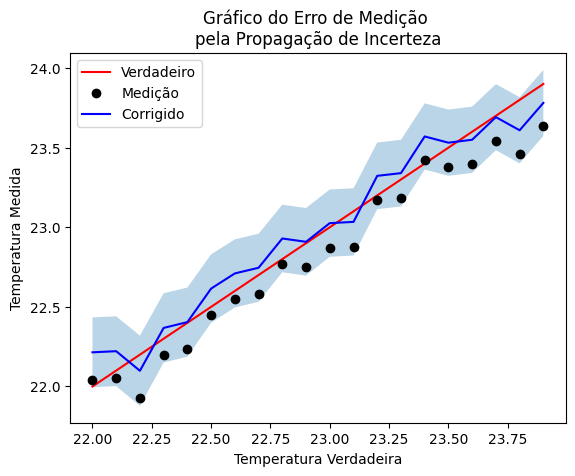

In [105]:
t_ref = np.arange(limite_inferior_teste, limite_superior_teste, passo_teste)
t_test = []
t_corrigido = []
t_superior_plot = []
t_inferior_plot = []

for t_verdadeira in t_ref:
  t_test.append(t_verdadeira + random.gauss(erro_sistematico, erro_aleatorio))

  b_pred = model_2.predict(t_test[-1])
  uc = np.sqrt(model_2.s_y1**2 + ((t_test[-1]-model_2.t0)**2)*(model_2.s_y2**2) + 2*(t_test[-1]-model_2.t0)*model_2.s_y1*model_2.s_y2*model_2.r)

  ip = np.sqrt(uc**2 + erro_aleatorio**2)*t_student

  t_corrigido.append(t_test[-1] + b_pred)
  t_superior_plot.append(t_corrigido[-1] + ip)
  t_inferior_plot.append(t_corrigido[-1] - ip)

plt.plot(t_ref, t_ref, 'r', label='Verdadeiro')
plt.plot(t_ref, t_test, 'ko', label='Medição')
plt.plot(t_ref, t_corrigido, 'b', label='Corrigido')
plt.fill_between(t_ref, t_superior_plot, t_inferior_plot, alpha=0.3)
plt.legend()
plt.title('Gráfico do Erro de Medição \npela Propagação de Incerteza')
plt.xlabel('Temperatura Verdadeira')
plt.ylabel('Temperatura Medida')

## 3.2 Avaliando a incerteza por Monte Carlo

In [106]:
num_simulacao = 100

Text(0, 0.5, 'Temperatura Medida')

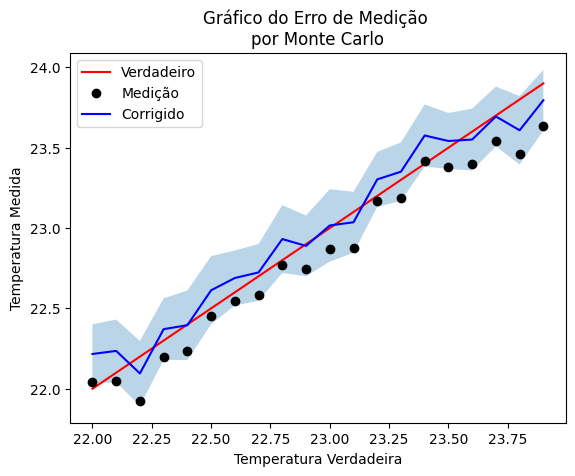

In [109]:
mc_temp_simulation = []
mc_std_pad = []
mc_superior = []
mc_inferior = []
for t_medido in t_test:

  mc_in_aux = []
  mc_temp_aux = []
  for i in range(num_simulacao):
    mc_in_aux.append(random.gauss(t_medido, erro_aleatorio))
    mc_temp_aux.append(mc_in_aux[-1] + model_2.predict(mc_in_aux[-1]))

  mc_temp_simulation.append(np.mean(mc_temp_aux))
  mc_std_pad.append(np.std(mc_temp_aux))
  mc_superior.append(mc_temp_simulation[-1] + mc_std_pad[-1]*t_student)
  mc_inferior.append(mc_temp_simulation[-1] - mc_std_pad[-1]*t_student)

plt.plot(t_ref, t_ref, 'r', label='Verdadeiro')
plt.plot(t_ref, t_test, 'ko', label='Medição')
plt.plot(t_ref, mc_temp_simulation, 'b', label='Corrigido')
plt.fill_between(t_ref, mc_superior, mc_inferior, alpha=0.3)
#plt.errorbar(t_ref, mc_temp_simulation, mc_std_pad, fmt='o', color='b', ecolor='lightgray', elinewidth=3, capsize=5)
plt.legend()
plt.title('Gráfico do Erro de Medição \npor Monte Carlo')
plt.xlabel('Temperatura Verdadeira')
plt.ylabel('Temperatura Medida')



## 3.3 Aplicação da Predição Conforme

Considerando como entrada do modelo o valor de leitura e como saída as diversas possibilidades simuladas por Monte Carlo, definir o indice de conformidade a partir destes dados.

#### Gerar os dados de simulação de MC

In [111]:
mc_cp_medicao = []
mc_cp_temp_simulation = []
mc_cp_b_simulation = []

for t_medido in t_test:
  for i in range(num_simulacao):
    mc_cp_medicao.append(t_medido)
    mc_cp_temp_simulation.append(random.gauss(t_medido, erro_aleatorio))
    mc_cp_b_simulation.append(model_2.predict(mc_cp_temp_simulation[-1]))

**O problema está por aqui**: a dúvida está onde que é b (fator de correção) e onde que é temp. medida e onde que é temp. corrigida que eu devo aplicar para o CP.

Talvez uma solução seja de transformar a curva de correção já em uma equação que retorno o valor corrigido e não apenas o fator de correção. O problema disso é que neste caso, não é possível

In [112]:
base_model = BasePredictor(model_2, is_trained=True)

split_cp = SplitCP(base_model, train=False)
split_cp.fit(X_calib=np.array(mc_cp_medicao).reshape(-1,1), y_calib=np.array(mc_cp_b_simulation).reshape(-1,1))

Text(0, 0.5, 'Temperatura Medida')

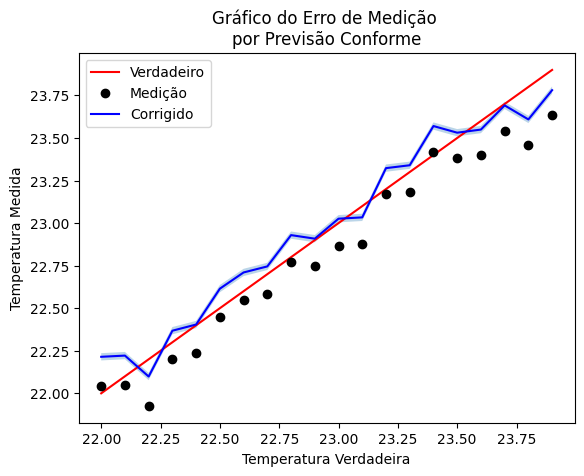

In [113]:
cp_temp = []
cp_superior = []
cp_inferior = []
for t_medido in t_test:
  y_pred, y_pred_lower, y_pred_upper = split_cp.predict(np.array(t_medido).reshape(-1,1), alpha=0.05)
  cp_temp.append(t_medido + y_pred)
  cp_superior.append(t_medido + y_pred_upper)
  cp_inferior.append(t_medido + y_pred_lower)


plt.plot(t_ref, t_ref, 'r', label='Verdadeiro')
plt.plot(t_ref, t_test, 'ko', label='Medição')
plt.plot(t_ref, cp_temp, 'b', label='Corrigido')
plt.fill_between(t_ref, cp_superior, cp_inferior, alpha=0.3)
plt.legend()
plt.title('Gráfico do Erro de Medição \npor Previsão Conforme')
plt.xlabel('Temperatura Verdadeira')
plt.ylabel('Temperatura Medida')